In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\processed\ethiopia_fi_enriched.csv")


Text(0, 0.5, '% of adults')

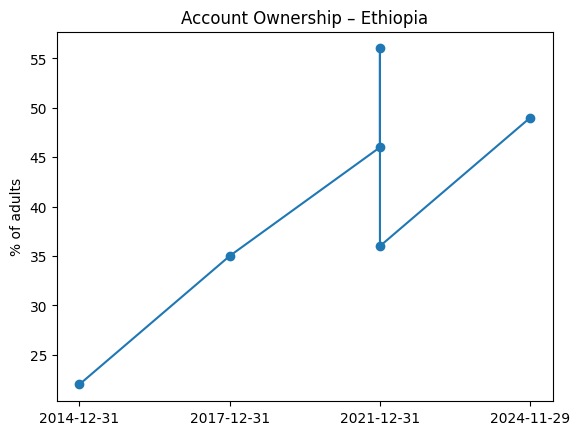

In [4]:
#Access Trends
access = df[
    (df["indicator_code"] == "ACC_OWNERSHIP") &
    (df["record_type"] == "observation")
].sort_values("observation_date")

plt.plot(access["observation_date"], access["value_numeric"], marker="o")
plt.title("Account Ownership – Ethiopia")
plt.ylabel("% of adults")


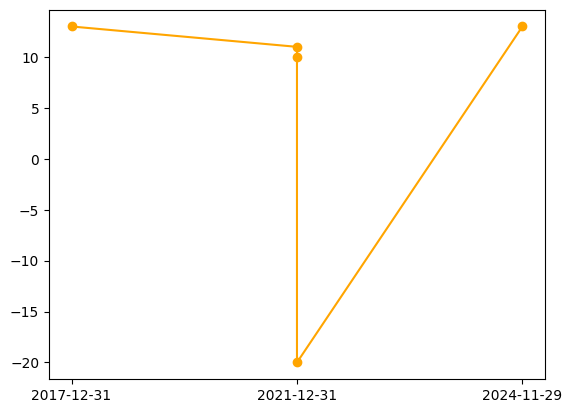

In [5]:
#Growth rate calculation
access["growth_pp"] = access["value_numeric"].diff()
plt.figure()
plt.plot(access["observation_date"],access["growth_pp"], marker="o",color="orange")

In [6]:
access = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "ACC_OWNERSHIP") &
    (df["source_name"].str.contains("Global Findex", na=False))
].copy()

access = access.sort_values("observation_date")


In [7]:
access[["observation_date", "value_numeric", "source_name"]]


,observation_date,value_numeric,source_name
0,2014-12-31,22.0,Global Findex 2014
1,2017-12-31,35.0,Global Findex 2017
2,2021-12-31,46.0,Global Findex 2021
3,2021-12-31,56.0,Global Findex 2021
4,2021-12-31,36.0,Global Findex 2021
5,2024-11-29,49.0,Global Findex 2024


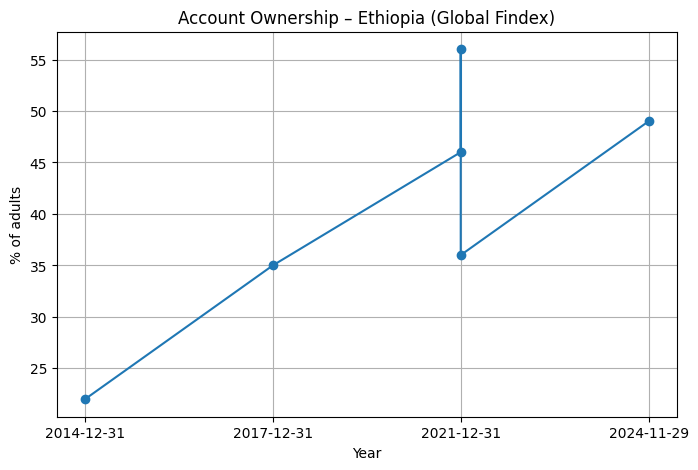

In [8]:
plt.figure(figsize=(8,5))
plt.plot(
    access["observation_date"],
    access["value_numeric"],
    marker="o"
)
plt.title("Account Ownership – Ethiopia (Global Findex)")
plt.ylabel("% of adults")
plt.xlabel("Year")
plt.grid(True)
plt.show()


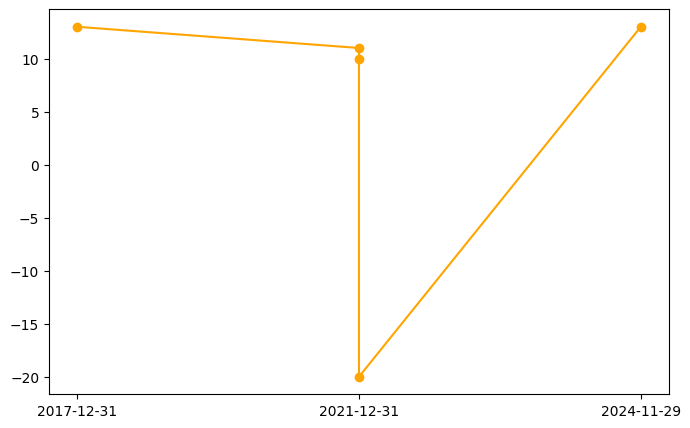

In [9]:
access["growth_pp"] = access["value_numeric"].diff()

access[["observation_date", "value_numeric", "growth_pp"]]
plt.figure(figsize=(8,5))
plt.plot(
    access["observation_date"],
    access["growth_pp"],
    marker="o",
    color="orange"
)

In [10]:
access_raw = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "ACC_OWNERSHIP") &
    (df["source_name"].str.contains("Global Findex", na=False))
]

access_raw [access_raw["observation_date"] == "2021-12-31"]


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [11]:
access = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "ACC_OWNERSHIP") &
    (df["source_name"].str.contains("Global Findex", na=False)) &
    (df["notes"].isna())
].copy()


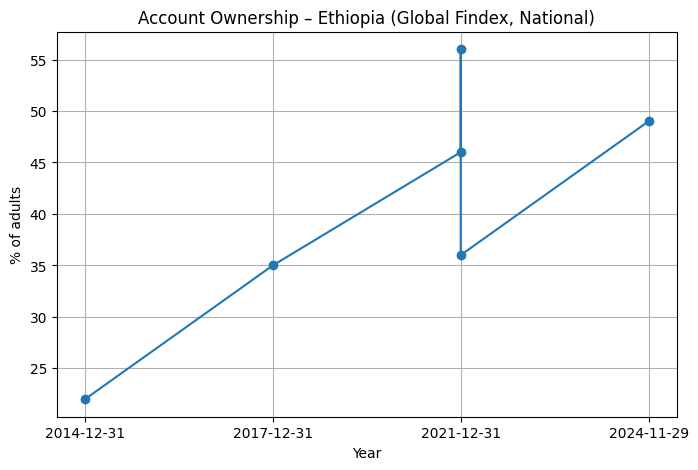

In [12]:
access = access.sort_values("observation_date")

plt.figure(figsize=(8,5))
plt.plot(
    access["observation_date"],
    access["value_numeric"],
    marker="o"
)
plt.title("Account Ownership – Ethiopia (Global Findex, National)")
plt.ylabel("% of adults")
plt.xlabel("Year")
plt.grid(True)
plt.show()


In [14]:
def plot_indicator_trend(df, indicator_code, title, ylabel):
    data = (
        df[df["indicator_code"] == indicator_code]
        .dropna(subset=["year", "value_numeric"])
        .sort_values("year")
    )

    if data.empty:
        print(f"⚠️ Skipping {indicator_code}: no numeric observations available.")
        return

    plt.figure(figsize=(8, 5))
    plt.plot(data["year"], data["value_numeric"], marker="o")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Year")
    plt.show()


In [18]:
obs = df[df["record_type"] == "observation"].copy()

obs["observation_date"] = pd.to_datetime(obs["observation_date"])
obs["year"] = obs["observation_date"].dt.year


In [16]:
obs = df[df["record_type"] == "observation"].copy()


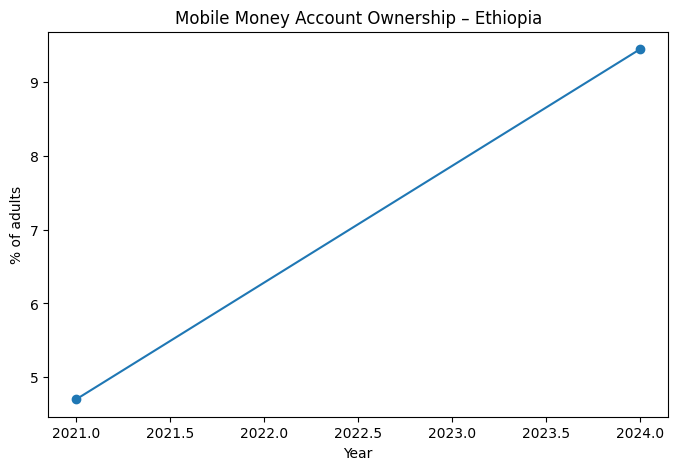

In [19]:
plot_indicator_trend(
    obs,
    indicator_code="ACC_MM_ACCOUNT",
    title="Mobile Money Account Ownership – Ethiopia",
    ylabel="% of adults"
)


In [21]:
# Correlation Scan
pivot = df.pivot_table(
    index="observation_date",
    columns="indicator_code",
    values="value_numeric"
)

pivot.corr()["ACC_OWNERSHIP"].sort_values(ascending=False)


indicator_code
ACC_OWNERSHIP         1.0
ACC_MM_ACCOUNT        1.0
GEN_GAP_ACC          -1.0
ACC_4G_COV            NaN
ACC_FAYDA             NaN
ACC_MOBILE_PEN        NaN
AFF_DATA_INCOME       NaN
GEN_GAP_MOBILE        NaN
GEN_MM_SHARE          NaN
USG_ACTIVE_RATE       NaN
USG_ATM_COUNT         NaN
USG_ATM_VALUE         NaN
USG_CROSSOVER         NaN
USG_MPESA_ACTIVE      NaN
USG_MPESA_USERS       NaN
USG_P2P_COUNT         NaN
USG_P2P_VALUE         NaN
USG_TELEBIRR_USERS    NaN
USG_TELEBIRR_VALUE    NaN
new_indicator         NaN
Name: ACC_OWNERSHIP, dtype: float64

In [24]:
impact.columns.tolist()


['record_id',
 'record_type',
 'category',
 'pillar',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'value_numeric',
 'value_text',
 'value_type',
 'unit',
 'observation_date',
 'period_start',
 'period_end',
 'fiscal_year',
 'gender',
 'location',
 'region',
 'source_name',
 'source_type',
 'source_url',
 'confidence',
 'related_indicator',
 'relationship_type',
 'impact_direction',
 'impact_magnitude',
 'impact_estimate',
 'lag_months',
 'evidence_basis',
 'comparable_country',
 'collected_by',
 'collection_date',
 'original_text',
 'notes']

In [25]:
impact.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes


In [26]:
impact_full = impact.merge(
    events,
    left_on="event_record_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)


KeyError: 'event_record_id'

In [27]:
impact = df[df["record_type"] == "impact_link"]
events = df[df["record_type"] == "event"]

impact_full = impact.merge(
    events,
    left_on="parent_id",
    right_on="id",
    suffixes=("_impact", "_event")
)


KeyError: 'id'